In [1]:
import numpy as np
import matplotlib.pyplot as plt 


In [2]:
import pandas as pd
import glob

In [3]:
#uses Sonora Diamondback models
#
# that have already been rebinned to SPIFF/SphereX resolution
# in notebook rebin_diamondback
#
# it is essentially identical to read_spiff 
#

In [4]:
#test
spiff_dir = '/Users/gizis/model_atmospheres/Diamondback/SPIFF/' 
name='t900g316f2_m-0.5_co1.0.spherex.csv'
testname = spiff_dir + name
testname


'/Users/gizis/model_atmospheres/Diamondback/SPIFF/t900g316f2_m-0.5_co1.0.spherex.csv'

In [5]:
# Read the CSV file
df = pd.read_csv(testname)

# View the first few rows
print(df.head())

   wavelength_um  flux_flambda
0       0.744000  3.282539e+08
1       0.765882  6.032121e+07
2       0.787765  4.887370e+08
3       0.809647  1.050184e+09
4       0.831529  1.506518e+09


In [6]:
#using Gemini AI to get advice even though I used to be able to figure this out myself with StackExchange and documentation
#
# Note that missing data points are turned into NaN. (Presumably they were NaN to start with and that's why they are missing!)  
#
# Some data exploration below and looking at the Zenodo 
#
# FOR MODELS, no data points should be missing!

In [7]:
# 1. Get all your file paths
#
# to include only the spectroscopically confirmed known brown dwarfs:
#file_paths = glob.glob('/Users/gizis/data/SPIFF/known_bds/csv/*.csv')
# this version also includes the previously know only by photometry:
#   possibly these are lower quality !?!?
file_paths = glob.glob('/Users/gizis/model_atmospheres/Diamondback/SPIFF/*.spherex.csv')

data_list = []

for f in file_paths:
    # Read only the first two columns (index 0 and 1)
    # 
    df = pd.read_csv(f, usecols=['wavelength_um', 'flux_flambda'])
    
    # 2. Set 'x' as the index
    # This is the "key" that Pandas uses to align different files
    df.set_index('wavelength_um', inplace=True)
    
    # 3. Rename the 'y' column to the filename 
    # This prevents column name collisions during the merge
    #
    df.columns = [f]
    
    data_list.append(df)

# 4. Concatenate side-by-side (axis=1)
# Pandas looks at the 'x' index and lines everything up.
# Missing x-values in any file will result in a NaN for that file.
combined_df = pd.concat(data_list, axis=1)

# 5. Sort the index 
# This ensures your columns (x-values) are in order (e.g., 1, 2, 3...)
combined_df.sort_index(inplace=True)

# 6. Transpose and convert to NumPy
# Now: Rows = Files, Columns = x-values
final_array = combined_df.T.to_numpy()

print(f"Array Shape: {final_array.shape}") # (Number of files, Number of unique x points)

Array Shape: (388, 102)


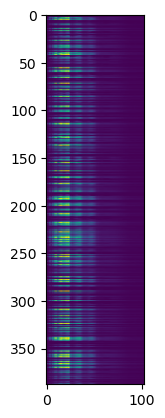

In [8]:
plt.imshow(final_array)

In [9]:
print(np.isnan(final_array).sum())


0


In [10]:
combined_df.index

Index([             0.744, 0.7658823562509873, 0.7877647125019747,
        0.809647068752962, 0.8315294250039493, 0.8534117812549367,
       0.8752941375059239, 0.8971764937569112, 0.9190588500078986,
        0.940941206258886,
       ...
        4.654941222246955,   4.68964708552641, 4.7243529488058655,
         4.75905881208532,  4.793764675364775,   4.82847053864423,
        4.863176401923685, 4.8978822652031395,  4.932588128482594,
        4.967293991762049],
      dtype='float64', name='wavelength_um', length=102)

In [14]:
#print("Filenames:", combined_df.columns.tolist())
filenames=combined_df.columns.tolist()

In [15]:
x_values = combined_df.index.to_numpy()
print(x_values)

[0.744      0.76588236 0.78776471 0.80964707 0.83152943 0.85341178
 0.87529414 0.89717649 0.91905885 0.94094121 0.96282356 0.98470592
 1.00658828 1.02847063 1.05035299 1.07223534 1.0941177  1.09899998
 1.13147057 1.16394116 1.19641175 1.22888234 1.26135293 1.29382352
 1.32629411 1.3587647  1.3912353  1.42370589 1.45617648 1.48864707
 1.52111766 1.55358825 1.58605884 1.61852943 1.63600004 1.68217651
 1.72835297 1.77452944 1.82070591 1.86688238 1.91305885 1.95923532
 2.00541179 2.05158825 2.09776472 2.14394119 2.19011766 2.23629413
 2.2824706  2.32864707 2.37482354 2.4230001  2.50529421 2.58758832
 2.66988244 2.75217655 2.83447066 2.91676478 2.99905889 3.08135301
 3.16364712 3.24594123 3.32823535 3.41052946 3.49282357 3.57511769
 3.6574118  3.73970591 3.80900002 3.8449412  3.88088238 3.91682356
 3.95276474 3.98870592 4.0246471  4.06058828 4.09652946 4.13247064
 4.16841182 4.204353   4.24029418 4.27623536 4.31217654 4.34811772
 4.3840589  4.41200018 4.44670604 4.48141191 4.51611777 4.5508

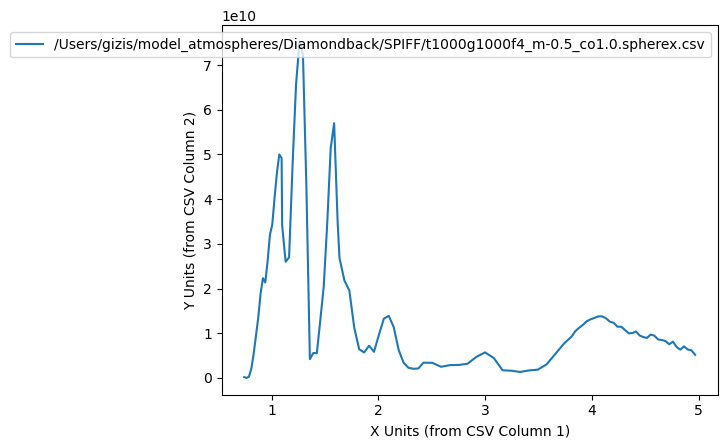

In [16]:
# plot random model
plt.plot(x_values, final_array[107], label=filenames[107]) 
plt.xlabel("X Units (from CSV Column 1)")
plt.ylabel("Y Units (from CSV Column 2)")
plt.legend()
plt.show()

In [17]:
import re

# Example filename from your list
#
# we can read Teff etc. if we wish to.  
filename = testname

# This pattern looks for 'moca_oid_' and captures all digits (\d+) following it
match = re.search(r't(\d+)', filename)

if match:
    teff = match.group(1)
    print(f"Extracted Teff: {teff}")

Extracted Teff: 900


In [30]:
# test extracting parameters using list comprehension.
# not actually used other that the next plot
teff_list = [re.search(r't(\d+)', f).group(1) for f in filenames if 't' in f]
#
# caution, this doesn't capture nc for no clouds!
cloud_list = [re.search(r'f(\d+)', f).group(1) for f in filenames if 'f' in f]
grav_list = [re.search(r'g(\d+)', f).group(1) for f in filenames if 'g' in f]
#
# would need to 
#met_list = [re.search(r'm(\d+)', f).group(1) for f in filenames if 'm' in f]
co_list = [re.search(r'co(\d+)', f).group(1) for f in filenames if 'co' in f]

#print(cloud_list)
# Output: ['1576818', '9988776']

AttributeError: 'NoneType' object has no attribute 'group'

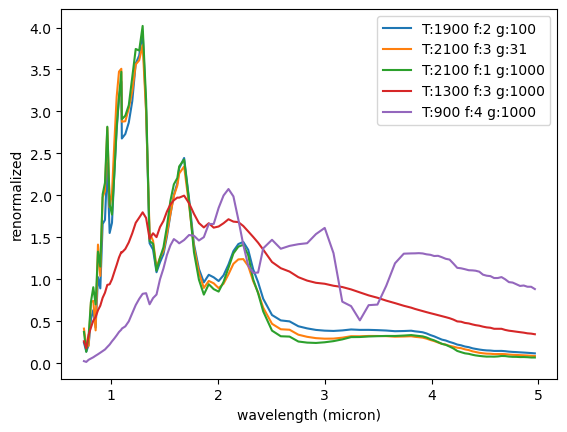

In [27]:
plt.plot(x_values, final_array[100]/np.nanmean(final_array[100]),label='T:'+teff_list[100]+' f:'+cloud_list[100]+' g:'+grav_list[100]) 
plt.plot(x_values, final_array[101]/np.nanmean(final_array[101]),label='T:'+teff_list[101]+' f:'+cloud_list[101]+' g:'+grav_list[101]) 
plt.plot(x_values, final_array[102]/np.nanmean(final_array[102]),label='T:'+teff_list[102]+' f:'+cloud_list[102]+' g:'+grav_list[102]) 
plt.plot(x_values, final_array[103]/np.nanmean(final_array[103]),label='T:'+teff_list[103]+' f:'+cloud_list[103]+' g:'+grav_list[103]) 
plt.plot(x_values, final_array[104]/np.nanmean(final_array[104]),label='T:'+teff_list[104]+' f:'+cloud_list[104]+' g:'+grav_list[104]) 
plt.xlabel('wavelength (micron)')
plt.ylabel("renormalized")
plt.legend()
plt.show()

In [20]:
combined_df.to_pickle('spiff_diamondback.pkl')

# To load it back later:
# combined_df = pd.read_pickle('spiff_all.pkl')

In [ ]:
# do not save x_values because already done in read_spiff
#np.save('spiff_xbins.npy',x_values)
